In [49]:
# %load std_ipython_import.txt
import pandas as pd
import numpy as np
import numpy.ma as ma
import matplotlib.pyplot as plt
import seaborn as sns
import pymc3 as pm
import theano.tensor as tt

from scipy.stats import norm

In [8]:
df = pd.read_csv('Salary.csv', usecols=[0,3,5], dtype={'Org': 'category', 'Pos': 'category'})


In [9]:
def gammaShRaFromModeSD(mode, sd):
    rate = (mode + np.sqrt( mode**2 + 4 * sd**2 ) ) / ( 2 * sd**2 )
    shape = 1 + mode * rate
    return(shape, rate)

In [17]:
y = df.Salary
yMean = y.mean()
ySD = y.std()

x1 = df.Pos.cat.codes.values
Nx1Lvl = len(df.Pos.cat.categories)

x2 = df.Org.cat.codes.values
Nx2Lvl = len(df.Org.cat.categories)

agammaShRa = gammaShRaFromModeSD(ySD/2 , 2*ySD)

with pm.Model() as model1:

    #a0 = pm.Normal('a0', yMean, tau=1/(ySD*5)**2)
    a0_tilde = pm.Normal('a0_tilde', mu=0, sd=1)
    a0 = pm.Deterministic('a0', yMean + ySD*5*a0_tilde)

    a1SD = pm.Gamma('a1SD', agammaShRa[0], agammaShRa[1])
    #a1 = pm.Normal('a1', 0.0, tau=1/a1SD**2, shape=Nx1Lvl)
    a1_tilde = pm.Normal('a1_tilde', mu=0, sd=1, shape=Nx1Lvl)
    a1 = pm.Deterministic('a1', 0.0 + a1SD*a1_tilde)

    a2SD = pm.Gamma('a2SD', agammaShRa[0], agammaShRa[1])
    #a2 = pm.Normal('a2', 0.0, tau=1/a2SD**2, shape=Nx2Lvl)
    a2_tilde = pm.Normal('a2_tilde', mu=0, sd=1, shape=Nx2Lvl)
    a2 = pm.Deterministic('a2', 0.0 + a2SD*a2_tilde)

    a1a2SD = pm.Gamma('a1a2SD', agammaShRa[0], agammaShRa[1])
    #a1a2 = pm.Normal('a1a2', 0.0, 1/a1a2SD**2, shape=(Nx1Lvl, Nx2Lvl))
    a1a2_tilde = pm.Normal('a1a2_tilde', mu=0, sd=1, shape=(Nx1Lvl, Nx2Lvl))
    a1a2 = pm.Deterministic('a1a2', 0.0 + a1a2SD*a1a2_tilde)

    mu = a0 + a1[x1] + a2[x2] +a1a2[x1, x2]
    ySigma = pm.Uniform('ySigma', ySD/100, ySD*10)

    like = pm.Normal('like', mu, sd=ySigma, observed=y)

In [19]:
a1[x1]

AdvancedSubtensor1.0

In [12]:
a2

a2 ~ Deterministic

In [127]:
factor_A = [0, 1]
factor_B = [0, 1]
N = np.array([250, 250, 250, 250])
purchase = np.array([20, 28, 12, 40])

with pm.Model() as model:
    fa = pm.Data('fa', factor_A)
    fb = pm.Data('fb', factor_B)

    beta0 = pm.Normal("beta0", mu=0, sd=10)
    beta1 = pm.Normal("beta1", mu=0, sd=10)
    beta2 = pm.Normal("beta2", mu=0, sd=10)

    comb = beta0 + beta1 * fa + beta2 * fb
    theta = pm.Deterministic('theta', pm.math.invlogit(comb))
    obs = pm.Binomial('obs', p=theta, n=N, observed=purchase)
    trace = pm.sample(1000, chains=1)

    #alpha = pm.Normal('alpha', mu=0, sigma=10)
    #beta = pm.Normal('beta', mu=0, sigma=10, shape=2)
    #@gamma = pm.Normal('gamma', mu=0, sigma=10)

    # a0 = pm.Normal('alpha', mu=0, sigma=10)
    #
    # a1_norm = pm.Normal('a1_norm', mu=0, sigma=10, shape=2)
    # a1 = pm.Deterministic('a1', a1_norm)
    #
    # a2_norm = pm.Normal('a2_norm', mu=0, sigma=10, shape=2)
    # a2 = pm.Deterministic('a2', a1_norm)
    #
    # comb = a0 + a1[factor_A] + a2[factor_B]
    #
    # #comb = alpha + beta[0] * factor_A + beta[1] * factor_B + gamma * factor_A * factor_B
    #
    # theta = pm.Deterministic('theta', 1 / (1 + pm.math.exp(-comb)))
    # obs = pm.Binomial('obs', p=theta, n=[250, 250], observed=[12, 40])
    # trace = pm.sample(5000, chains=2)

ValueError: Input dimension mis-match. (input[0].shape[0] = 4, input[1].shape[0] = 2)

In [23]:
factor_A

['grid', 'list']

ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 2 dimension(s) and the array at index 1 has 1 dimension(s)

In [39]:
np.vstack([factors[:,0], [.T])

array([[0, 0, 1, 1],
       [0, 0, 0, 0]])

In [81]:
factor_A = [0, 1, 2]
factor_B = [0, 1]
N = np.array([250, 250, 250, 250, 250, 250])
purchase = np.array([20, 28, 12, 40, 40, 60])

from itertools import product
factors = np.array(list(product(factor_A, factor_B)))
factors

array([[0, 0],
       [0, 1],
       [1, 0],
       [1, 1],
       [2, 0],
       [2, 1]])

In [84]:
data = np.vstack([factors[:, 0], factors[:, 1], purchase, N]).T
df = pd.DataFrame(data, columns=['factor_A', 'factor_B', 'purchase', 'trials'])
df

,factor_A,factor_B,purchase,trials
0,0,0,20,250
1,0,1,28,250
2,1,0,12,250
3,1,1,40,250
4,2,0,40,250
5,2,1,60,250


In [86]:
with pm.Model() as model:
    a0 = pm.Normal('alpha', mu=0, sigma=10)

    a1 = pm.Normal('a1', mu=0, sigma=10, shape=3)

    a2 = pm.Normal('a2', mu=0, sigma=10, shape=2)

    a1a2 = pm.Normal('a1a2', mu=0, sigma=10, shape=(3, 2))

    comb = a0 + a1[df.factor_A] + a2[df.factor_B] + a1a2[df.factor_A, df.factor_B]

    theta = pm.Deterministic('theta', pm.invlogit(comb))
    y = pm.Binomial('y', n=df.trials, observed=df.purchase, p=theta)
    trace = pm.sample(5000, chains=1)

/var/folders/4_/vrr8kzqn5b9dxsprxn13022m0000gn/T/ipykernel_66891/2265279870.py:14: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  trace = pm.sample(5000, chains=1)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [a1a2, a2, a1, alpha]


/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 1 chain for 1_000 tune and 5_000 draw iterations (1_000 + 5_000 draws total) took 99 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


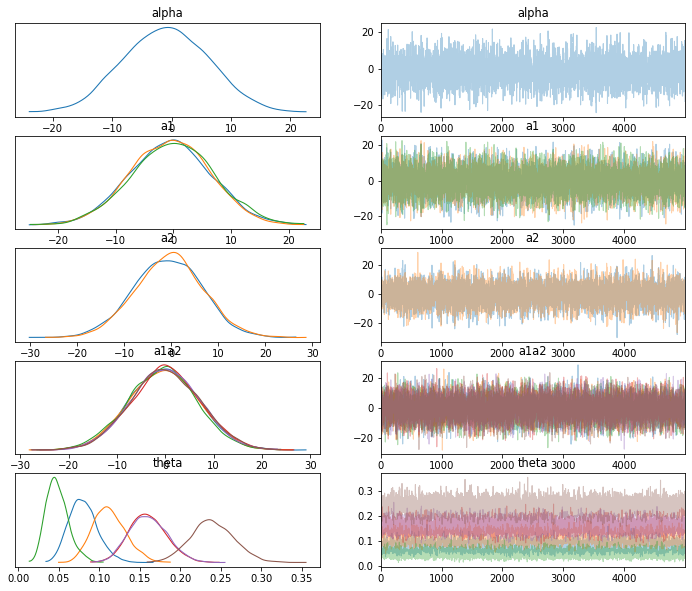

In [87]:
import arviz as az

with model:
    az.plot_trace(trace)

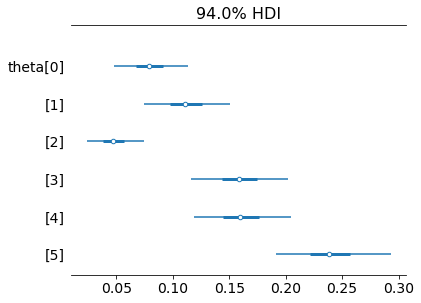

In [88]:
with model:
    az.plot_forest(trace, var_names=['theta'], combined=True)

In [90]:
iris = pd.read_csv('iris.csv')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


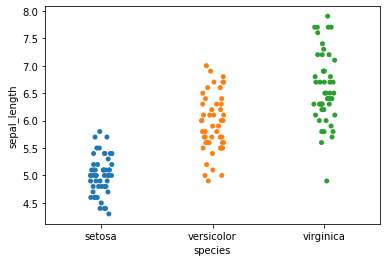

In [91]:
sns.stripplot(x='species', y='sepal_length', data=iris, jitter=True)

In [92]:
df = iris.query("species == ('setosa', 'versicolor')")

In [93]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
95,5.7,3.0,4.2,1.2,versicolor
96,5.7,2.9,4.2,1.3,versicolor
97,6.2,2.9,4.3,1.3,versicolor
98,5.1,2.5,3.0,1.1,versicolor


In [94]:
y_0 = pd.Categorical(df['species']).codes

In [96]:
x_n = 'sepal_length'

In [98]:
x_0 = df[x_n].values
x_c = x_0 - x_0.mean()

In [104]:
with pm.Model() as model_0:
    α = pm.Normal('α', mu=0, sd=10)
    β = pm.Normal('β', mu=0, sd=10)

    μ = α + pm.math.dot(x_c, β)
    θ = pm.Deterministic('θ', pm.math.sigmoid(μ))
    bd = pm.Deterministic('bd', -α/β)

    yl = pm.Bernoulli('yl', p=θ, observed=y_0)

    trace_0 = pm.sample(1000)

/var/folders/4_/vrr8kzqn5b9dxsprxn13022m0000gn/T/ipykernel_66891/3130842670.py:11: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  trace_0 = pm.sample(1000)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [β, α]


/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.


/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/arviz/plots/hdiplot.py:157: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


([<matplotlib.axis.XTick at 0x16b33f760>,
 [Text(0, 0, '4.0'),
  Text(0, 0, '4.5'),
  Text(0, 0, '5.0'),
  Text(0, 0, '5.5'),
  Text(0, 0, '6.0'),
  Text(0, 0, '6.5'),
  Text(0, 0, '7.0'),
  Text(0, 0, '7.5')])

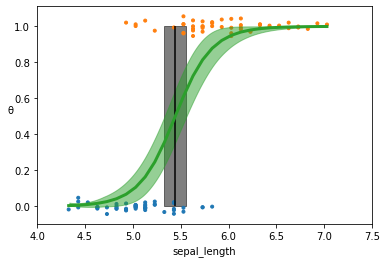

In [110]:
theta = trace_0['θ'].mean(axis=0)
idx = np.argsort(x_c)
plt.plot(x_c[idx], theta[idx], color='C2', lw=3)
plt.vlines(trace_0['bd'].mean(), 0, 1, color='k')
bd_hpd = az.hdi(trace_0['bd'])
plt.fill_betweenx([0, 1], bd_hpd[0], bd_hpd[1], color='k', alpha=0.5)

plt.scatter(x_c, np.random.normal(y_0, 0.02),
            marker='.', color=[f'C{x}' for x in y_0])
az.plot_hdi(x_c, trace_0['θ'], color='C2')

plt.xlabel(x_n)
plt.ylabel('θ', rotation=0)
# use original scale for xticks
locs, _ = plt.xticks()
plt.xticks(locs, np.round(locs + x_0.mean(), 1))

In [111]:
df = iris.query("species == ('setosa', 'versicolor')")
y_1 = pd.Categorical(df['species']).codes
x_n = ['sepal_length', 'sepal_width']
x_1 = df[x_n].values

In [112]:
with pm.Model() as model_1:
    α = pm.Normal('α', mu=0, sd=10)
    β = pm.Normal('β', mu=0, sd=2, shape=len(x_n))

    μ = α + pm.math.dot(x_1, β)
    θ = pm.Deterministic('θ', 1 / (1 + pm.math.exp(-μ)))
    bd = pm.Deterministic('bd', -α/β[1] - β[0]/β[1] * x_1[:,0])

    yl = pm.Bernoulli('yl', p=θ, observed=y_1)

    trace_1 = pm.sample(2000)

/var/folders/4_/vrr8kzqn5b9dxsprxn13022m0000gn/T/ipykernel_66891/633379677.py:11: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  trace_1 = pm.sample(2000)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [β, α]


/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 12 seconds.
There were 2 divergences after tuning. Increase `target_accept` or reparameteriz

In [115]:
x_1

array([[5.1, 3.5],
       [4.9, 3. ],
       [4.7, 3.2],
       [4.6, 3.1],
       [5. , 3.6],
       [5.4, 3.9],
       [4.6, 3.4],
       [5. , 3.4],
       [4.4, 2.9],
       [4.9, 3.1],
       [5.4, 3.7],
       [4.8, 3.4],
       [4.8, 3. ],
       [4.3, 3. ],
       [5.8, 4. ],
       [5.7, 4.4],
       [5.4, 3.9],
       [5.1, 3.5],
       [5.7, 3.8],
       [5.1, 3.8],
       [5.4, 3.4],
       [5.1, 3.7],
       [4.6, 3.6],
       [5.1, 3.3],
       [4.8, 3.4],
       [5. , 3. ],
       [5. , 3.4],
       [5.2, 3.5],
       [5.2, 3.4],
       [4.7, 3.2],
       [4.8, 3.1],
       [5.4, 3.4],
       [5.2, 4.1],
       [5.5, 4.2],
       [4.9, 3.1],
       [5. , 3.2],
       [5.5, 3.5],
       [4.9, 3.6],
       [4.4, 3. ],
       [5.1, 3.4],
       [5. , 3.5],
       [4.5, 2.3],
       [4.4, 3.2],
       [5. , 3.5],
       [5.1, 3.8],
       [4.8, 3. ],
       [5.1, 3.8],
       [4.6, 3.2],
       [5.3, 3.7],
       [5. , 3.3],
       [7. , 3.2],
       [6.4, 3.2],
       [6.9,

/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/arviz/plots/hdiplot.py:157: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


Text(0, 0.5, 'sepal_width')

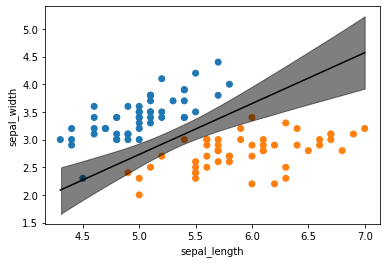

In [114]:
idx = np.argsort(x_1[:,0])
bd = trace_1['bd'].mean(0)[idx]
plt.scatter(x_1[:,0], x_1[:,1], c=[f'C{x}' for x in y_0])
plt.plot(x_1[:,0][idx], bd, color='k');

az.plot_hdi(x_1[:,0], trace_1['bd'], color='k')

plt.xlabel(x_n[0])
plt.ylabel(x_n[1])

In [116]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_style(style="darkgrid", rc={"axes.facecolor": ".9", "grid.color": ".8"})
sns.set_palette(palette="deep")
sns_c = sns.color_palette(palette="deep")

import arviz as az
import patsy
import pymc3 as pm

from pymc3 import glm

plt.rcParams["figure.figsize"] = [7, 6]
plt.rcParams["figure.dpi"] = 100

In [117]:
SEED = 42
np.random.seed(SEED)

# Number of data points.
n = 250
# Create features.
x1 = np.random.normal(loc=0.0, scale=2.0, size=n)
x2 = np.random.normal(loc=0.0, scale=2.0, size=n)
epsilon = np.random.normal(loc=0.0, scale=0.5, size=n)
# Define target variable.
intercept = -0.5
beta_x1 = 1
beta_x2 = -1
beta_interaction = 2
z = intercept + beta_x1 * x1 + beta_x2 * x2 + beta_interaction * x1 * x2
p = 1 / (1 + np.exp(-z))
y = np.random.binomial(n=1, p=p, size=n)

df = pd.DataFrame(dict(x1=x1, x2=x2, y=y))

df.head()

,x1,x2,y
0,0.993428,-2.521768,0
1,-0.276529,1.835724,0
2,1.295377,4.244312,1
3,3.046060,2.064931,1
4,-0.468307,-3.038740,1


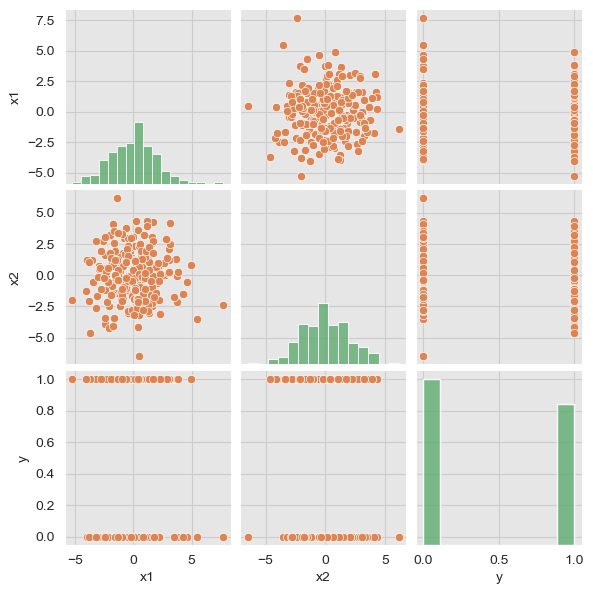

In [118]:
sns.pairplot(
    data=df, kind="scatter", height=2, plot_kws={"color": sns_c[1]}, diag_kws={"color": sns_c[2]}
);

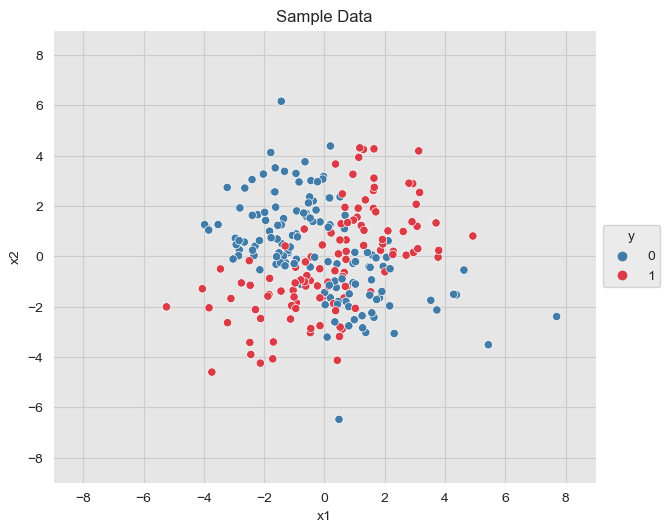

In [119]:
fig, ax = plt.subplots()
sns_c_div = sns.diverging_palette(240, 10, n=2)
sns.scatterplot(x="x1", y="x2", data=df, hue="y", palette=[sns_c_div[0], sns_c_div[-1]])
ax.legend(title="y", loc="center left", bbox_to_anchor=(1, 0.5))
ax.set(title="Sample Data", xlim=(-9, 9), ylim=(-9, 9));

In [120]:
# Define model formula.
formula = "y ~ x1 * x2"
# Create features.
y, x = patsy.dmatrices(formula_like=formula, data=df)
y = np.asarray(y).flatten()
labels = x.design_info.column_names
x = np.asarray(x)

In [121]:
print(f"labels = {labels}")

labels = ['Intercept', 'x1', 'x2', 'x1:x2']


In [122]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.7, random_state=SEED)

In [125]:
x_train

array([[ 1.00000000e+00,  2.95578809e+00,  1.51609116e-01,
         4.48124420e-01],
       [ 1.00000000e+00, -5.83387500e-01, -7.70627194e-01,
         4.49574272e-01],
       [ 1.00000000e+00, -1.98107265e+00,  1.74464127e+00,
        -3.45626111e+00],
       [ 1.00000000e+00, -3.97513783e+00,  1.25669102e+00,
        -4.99552001e+00],
       [ 1.00000000e+00,  1.83080424e+00, -1.65099439e+00,
        -3.02264753e+00],
       [ 1.00000000e+00, -4.68273914e-01, -9.68468146e-01,
         4.53508369e-01],
       [ 1.00000000e+00, -1.67843505e+00,  2.55532979e+00,
        -4.28895508e+00],
       [ 1.00000000e+00,  9.46475249e-01,  3.25723109e+00,
         3.08288861e+00],
       [ 1.00000000e+00,  4.32917179e-01, -1.91108088e+00,
        -8.27339744e-01],
       [ 1.00000000e+00, -1.77902886e+00,  4.12149585e+00,
        -7.33226006e+00],
       [ 1.00000000e+00,  2.71248006e+00,  4.20076833e-02,
         1.13945003e-01],
       [ 1.00000000e+00,  4.54919869e-01, -1.79682934e+00,
      

['Intercept', 'x1', 'x2', 'x1:x2']

In [123]:
with pm.Model() as model:
    # Set data container.
    data = pm.Data("data", x_train)
    # Define GLM family.
    family = pm.glm.families.Binomial()
    # Set priors.
    priors = {
        "Intercept": pm.Normal.dist(mu=0, sd=10),
        "x1": pm.Normal.dist(mu=0, sd=10),
        "x2": pm.Normal.dist(mu=0, sd=10),
        "x1:x2": pm.Normal.dist(mu=0, sd=10),
    }
    # Specify model.
    glm.GLM(y=y_train, x=data, family=family, intercept=True, labels=labels, priors=priors)
    # Configure sampler.
    trace = pm.sample(5000, chains=5, tune=1000, target_accept=0.87, random_seed=SEED)

/var/folders/4_/vrr8kzqn5b9dxsprxn13022m0000gn/T/ipykernel_66891/120372097.py:16: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  trace = pm.sample(5000, chains=5, tune=1000, target_accept=0.87, random_seed=SEED)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (5 chains in 4 jobs)
NUTS: [x1:x2, x2, x1, Intercept]


/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost

Got error No model on context stack. trying to find log_likelihood in translation.
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/arviz/data/io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(
Got error No model on context stack. trying to find log_likelihood in translation.


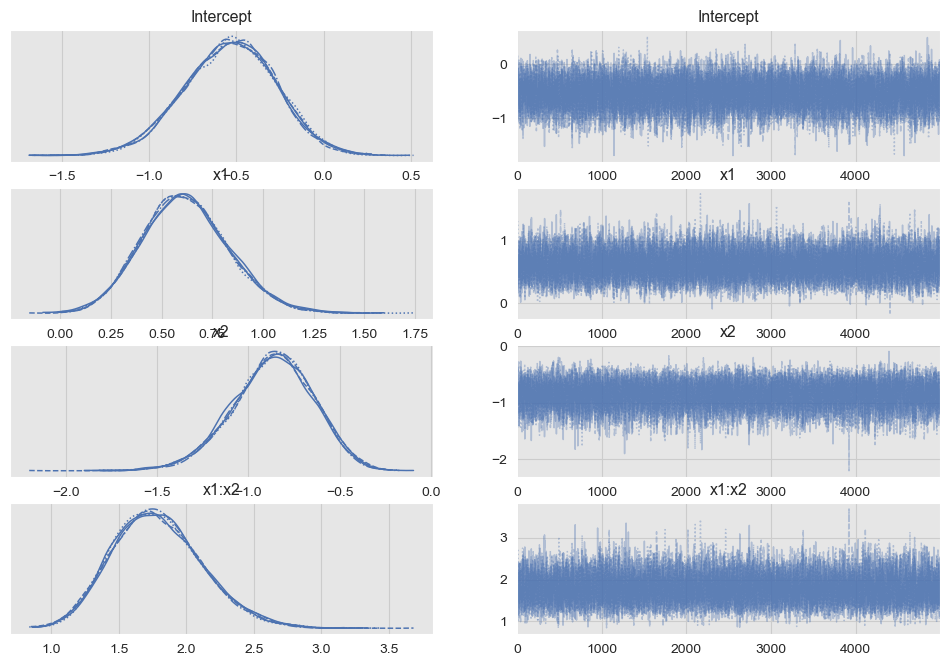

In [124]:
# Plot chains.
az.plot_trace(data=trace);